# Simulating RB data

An RB experiment design gives you circuits, not data. To get data without a device you need a model that can simulate those circuits, and RB circuits are picky about what a model must support. This page generates one set of Clifford RB circuits and simulates it two ways: with an *explicit* model carrying full $n$-qubit process matrices, and with an *implicit* model built from smaller pieces.

The two routes trade generality against scale. Explicit models let you write down any $n$-qubit process matrix you like, including correlated noise across all the qubits, but the matrices are $4^n \times 4^n$, so you are practically limited to two or three qubits. Implicit models assemble the layer operations on the fly from per-gate building blocks, which scales much further, at the cost of restricting what noise you can express.

In [1]:
import pygsti
import numpy as np

from pygsti.processors import QubitProcessorSpec
from pygsti.processors import CliffordCompilationRules as CCR

## Get some CRB circuits

Follow the [Clifford RB](../../guides/rb/CliffordRB) tutorial to generate a set of sequences. For Direct RB instead, replace this cell with the contents of the [Direct RB](../../guides/rb/DirectRB) tutorial up to the point where it creates `circuitlist`.

In [2]:
#Specify the device to be benchmarked - in this case 2 qubits
n_qubits = 2
qubit_labels = [0,1]
gate_names = ['Gxpi2', 'Gypi2','Gcphase']
availability = {'Gcphase':[(0,1)]}
pspec = QubitProcessorSpec(n_qubits, gate_names, availability=availability,
                                 qubit_labels=qubit_labels)

compilations = {'absolute': CCR.create_standard(pspec, 'absolute', ('paulis', '1Qcliffords'), verbosity=0),
                'paulieq': CCR.create_standard(pspec, 'paulieq', ('1Qcliffords', 'allcnots'), verbosity=0)}

#Specify RB parameters (k = number of repetitions at each length)
lengths = [0,1,2,4,8,16]
k = 10
subsetQs = [0,1]
randomizeout = False # ==> all circuits have the *same* ideal outcome (the all-zeros bitstring)

#Generate clifford RB circuits
exp_design = pygsti.protocols.CliffordRBDesign(pspec, compilations, lengths, k,
                                               qubit_labels=subsetQs, randomizeout=randomizeout)

#Collect all the circuits into one list:
circuitlist = exp_design.all_circuits_needing_data

- Sampling 10 circuits at CRB length 0 (1 of 6 depths) with seed 889802
- Sampling 10 circuits at CRB length 1 (2 of 6 depths) with seed 889812
- Sampling 10 circuits at CRB length 2 (3 of 6 depths) with seed 889822
- Sampling 10 circuits at CRB length 4 (4 of 6 depths) with seed 889832
- Sampling 10 circuits at CRB length 8 (5 of 6 depths) with seed 889842
- Sampling 10 circuits at CRB length 16 (6 of 6 depths) with seed 889852


## What the model has to handle

Two features of these circuits constrain the model you simulate them with:

1. RB circuits use pyGSTi's "multi-qubit" gate naming, so you have gates like `Gxpi2:0` and `Gcphase:0:1`.
2. RB circuits do gates in parallel (this only matters for >1 qubits), so you have layers like `[Gypi2:0Gypi2:1]`.

Both model types below produce the right gate names. They differ on parallel layers: an implicit model builds the layer operator on demand, while an explicit model only knows the operations you put in it, so parallel layers need a workaround.

## Explicit model: arbitrary $n$-qubit process matrices

Build the model from the standard 2-qubit X, Y, CPHASE model pack, which already has the right gates. A model pack packages a `Model` object with the meta information other protocols (like GST) need. If you can't start from a standard model, create an `ExplicitOpModel` of the appropriate dimension (see the [explicit models tutorial](../../guides/models/Models)) and assign gates keyed by, for instance, `('Gxpi2',0)` rather than plain `'Gxpi2'`.

In [3]:
from pygsti.modelpacks import smq2Q_XYCPHASE

Depolarize the target model, then overwrite one process matrix with a custom value as a demonstration. This is where you can set any 2-qubit process matrix you want on any of the gates:

In [4]:
myModel = smq2Q_XYCPHASE.target_model().depolarize(op_noise=0.01, spam_noise=0.01)
myModel[('Gxpi2',0)] = np.kron(
    np.array([[1, 0, 0, 0],
              [0, 0.85, 0, 0],
              [0, 0, 0, -0.85],
              [0, 0, 0.85, 0]], 'd'),
    np.array([[1, 0, 0, 0],
              [0, 0.95, 0, 0],
              [0, 0, 0.95, 0],
              [0, 0, 0, 0.95]], 'd'))
myModel.operations.keys() #voila! you have gates like "Gxpi2:0" rather than "Gxi"

odict_keys([Label(('Gxpi2', 1)), Label(('Gypi2', 1)), Label(('Gxpi2', 0)), Label(('Gypi2', 0)), Label(('Gcphase', 0, 1))])

`ExplicitOpModel` objects (the model packs included) don't know how to simulate several gates in parallel; you'd have to add an operation for every layer that occurs. The cheap way around this is to *serialize* the circuits so no layer contains more than one gate. Then simulate, producing a `DataSet`.

In [5]:
serial_circuits = [c.serialize() for c in circuitlist]
ds_explicit = pygsti.data.simulate_data(myModel, serial_circuits, 100, seed=1234)

#See how the DataSet contains serialized circuits (just printing the first several layers for clarity)
print(circuitlist[10][0:5]) # Original
print(list(ds_explicit.keys())[10][0:7]) # Serialized

Qubit 0 ---|Gypi2|-|Gxpi2|-|C1|-|Gxpi2|-|Gxpi2|---
Qubit 1 ---|Gxpi2|-|Gypi2|-|C0|-|Gypi2|-|Gypi2|---

Qubit 0 ---|Gypi2|-|     |-|Gxpi2|-|     |-|C1|-|Gxpi2|-|     |---
Qubit 1 ---|     |-|Gxpi2|-|     |-|Gypi2|-|C0|-|     |-|Gypi2|---



The RB experiment design calls for the original parallel-gate circuits, not the serialized ones, so un-serialize the circuits in the resulting data set with `process_circuits`. The cell below relabels every circuit in the simulated data so the counts are associated with the circuits the design expects.

In [6]:
#map circuits in dataset back to non-serialized RB circuits that we expect to have data for:
unserialize_map = { serial_circuit: orig_circuit for (serial_circuit, orig_circuit) in zip(serial_circuits, circuitlist)}
ds_explicit = ds_explicit.process_circuits(lambda c: unserialize_map[c])

## Implicit model: local noise on each gate

Implicit models (see the [implicit model tutorial](../../guides/models/MultiQubitModels)) describe multi-qubit processors efficiently, and they handle parallel-gate layers natively, so no serialization step is needed. There are several ways to construct one. The simplest is a "local noise model" (class `LocalNoiseModel`), in which the noise on a gate acts only on that gate's target qubits: 1-qubit gates stay 1-qubit operators rather than becoming $n$-qubit ones.

`create_crosstalk_free_model` builds a `LocalNoiseModel` from a `QubitProcessorSpec`.

In [7]:
myImplicitModel = pygsti.models.create_crosstalk_free_model(pspec, ideal_gate_type='full')
myImplicitModel.sim = 'map'

`ideal_gate_type='full'` matters, since it's what lets you assign arbitrary numpy arrays to the gates below. For gates that aren't built into pyGSTi, define their unitaries in the `nonstd_gate_unitaries` argument of `QubitProcessorSpec` (see its docstring).

The model comes back with ideal (perfect) gates. Make a 1-qubit depolarization superoperator and a 2-qubit one (just the tensor product of two 1-qubit ones) to add some simple noise:

In [8]:
depol1Q = np.array([[1, 0,   0, 0],
                    [0, 0.99, 0, 0],
                    [0, 0, 0.99, 0],
                    [0, 0, 0, 0.99]], 'd') # 1-qubit depolarizing operator
depol2Q = np.kron(depol1Q,depol1Q)

A `LocalNoiseModel` holds its gate operations in `.operation_blks['gates']`. Assign a new process matrix to each gate, here just a depolarized version of the original:

In [9]:
myImplicitModel.operation_blks['gates']["Gxpi2"] = np.dot(depol1Q, myImplicitModel.operation_blks['gates']["Gxpi2"].to_dense())
myImplicitModel.operation_blks['gates']["Gypi2"] = np.dot(depol1Q, myImplicitModel.operation_blks['gates']["Gypi2"].to_dense())
myImplicitModel.operation_blks['gates']["Gcphase"] = np.dot(depol2Q, myImplicitModel.operation_blks['gates']["Gcphase"].to_dense())

Here's what the gates look like now:

In [10]:
print(myImplicitModel.operation_blks['gates']["Gxpi2"])
print(myImplicitModel.operation_blks['gates']["Gypi2"])
print(myImplicitModel.operation_blks['gates']["Gcphase"])

<pygsti.modelmembers.operations.fullarbitraryop.FullArbitraryOp object at 0xADDRESS>
<pygsti.modelmembers.operations.fullarbitraryop.FullArbitraryOp object at 0xADDRESS>
<pygsti.modelmembers.operations.fullarbitraryop.FullArbitraryOp object at 0xADDRESS>


Simulating is a one-liner, and the circuits go in as they came out of the design:

In [11]:
ds_implicit = pygsti.data.simulate_data(myImplicitModel, circuitlist, 100, seed=1234)

## Running RB on the simulated data sets

Package the experiment design and a data set into a `ProtocolData` object and hand it to the `RB` protocol's `run` method. That returns a `RandomizedBenchmarkingResults` object, which can plot the RB decay curve.

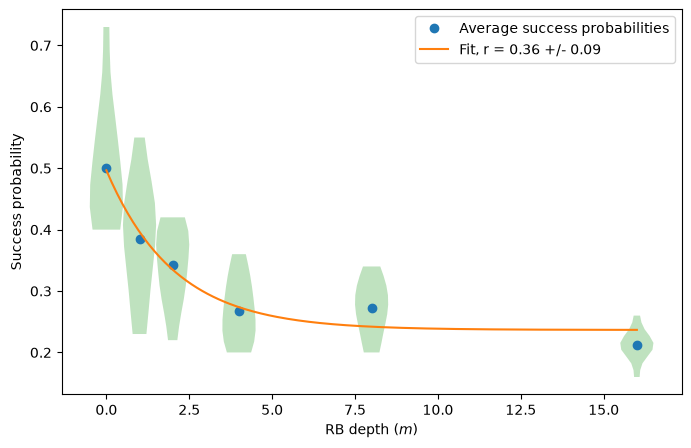

In [12]:
%matplotlib inline
data_explicit = pygsti.protocols.ProtocolData(exp_design, ds_explicit)
results_explicit = pygsti.protocols.RB().run(data_explicit)
results_explicit.plot()

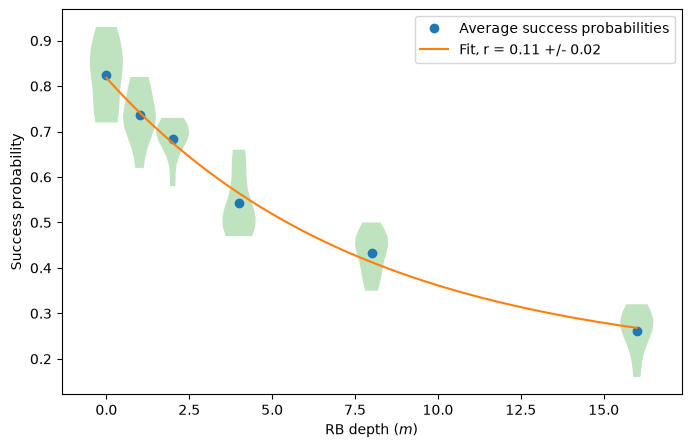

In [13]:
data_implicit = pygsti.protocols.ProtocolData(exp_design, ds_implicit)
results_implicit = pygsti.protocols.RB().run(data_implicit)
results_implicit.plot()

The two decay rates aren't meant to agree: the models carry different noise. What they share is the workflow, and the choice between them is about how big $n$ gets and how correlated the noise you need to describe is.